In [1]:
import jax
import jax.numpy as jnp
import systems
import observers
import plotting

# Toy car

\begin{align}
\ddot{x} &= F/m  \\
y &= x
\end{align}

\begin{align}

    \begin{bmatrix}
        \dot{x} \\
        \ddot{x}
    \end{bmatrix} 

&=
    \begin{bmatrix}
        0 \;\;\; 1 \\
        0 \;\;\; 0 \\
    \end{bmatrix}

    \begin{bmatrix}
        x \\
        \dot{x}
    \end{bmatrix}

    + 

    \begin{bmatrix}
        0 \\
        1/m
    \end{bmatrix}

    F

\\

    y 

&=

    \begin{bmatrix}
        1 \;\;\; 0
    \end{bmatrix}

    \begin{bmatrix}
        x \\
        \dot{x}
    \end{bmatrix}
    
\end{align}


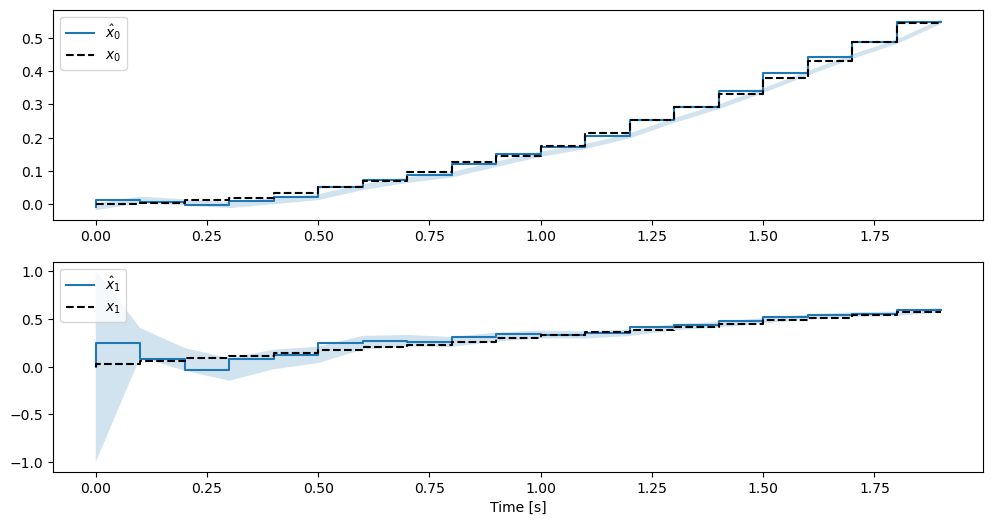

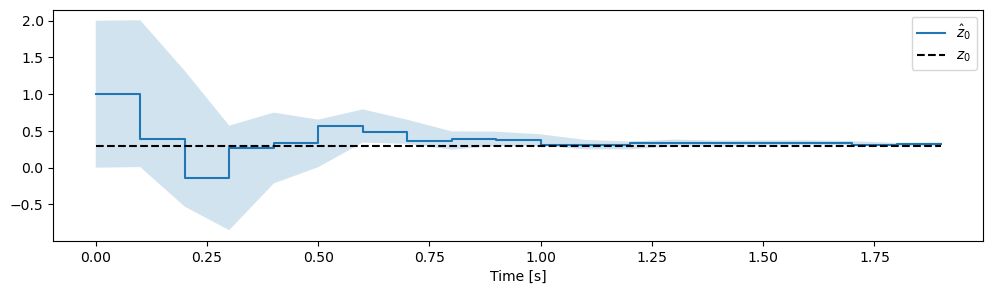

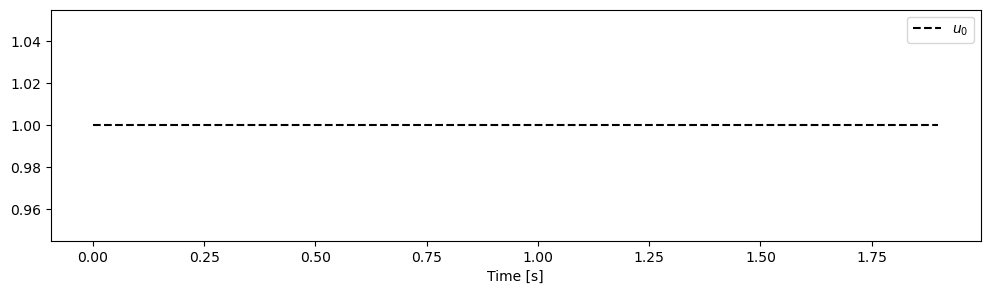

In [2]:
# define the system
dssm = systems.DSSM.from_continuos(
    A=jnp.array([[0, 1], [0, 0]]),
    B=jnp.array([[0], [1]]),
    C=jnp.array([[1, 0]]),
    D=None,
    noise_std_x=jnp.ones(2) * 1e-2,
    noise_std_y=jnp.ones(1) * 1e-2,
    dt=0.1,
)

# define the input and the fault signal
rng_key = jax.random.PRNGKey(0)
x0 = jnp.zeros(dssm.state_dim)
t = jnp.arange(0, 2, dssm.dt)
u_t = jnp.ones((len(t), dssm.input_dim))
z_t = 0.3 * jnp.ones_like(u_t)

# simulate the system and the observer
_, x_t, y_t = dssm.simulate(x0, rng_key, u_t * z_t)
observer = observers.FaultObserver.from_dssm(dssm)
x_est, z_est = jax.vmap(observer.split)(observer.simulate(u_t, y_t))

# plot the results
plotting.plot_sim_result(t, u_t=u_t, x_t=x_t, x_est=x_est, z_t=z_t, z_est=z_est)

# 3 tank system

$S_n = 5 \times 10^{-5} \; [m^2]$ connector cross-section

$S_a = 1.54 \times 10^{-2} \; [m^2]$ tank cross-section

$a z = \left(\begin{matrix} 
    0.46\\
    0.48\\
    0.58
\end{matrix}\right)$ outflow coefficients

$h^* = \left(\begin{matrix} 
    0.489 \\
    0.2332\\
    0.3611
\end{matrix}\right) [m]$ liquid levels at equilibrium

$k = \frac{g S_n}{S_a \sqrt{2 g}}$
$a_1 = \frac{a z_1 k}{\sqrt{(h^*_1-h^*_3)}}$
$a_2 = \frac{a z_3 k}{\sqrt{(h^*_3-h^*_2)}}$
$a_3 = \frac{a z_2 k}{\sqrt{(h^*_2)}}$

when linearized on $(h^*_1,h^*_2,h^*_3)$ (assume $h^*_1>h^*_3>h^*_2$)

$A = \left|\begin{matrix} 
    -\frac{a z_1 g S_n}{S_a \sqrt{2 g (h^*_1-h^*_3)}}, &
    0, & 
    \frac{a z_1 g S_n}{S_a \sqrt{2 g (h^*_1-h^*_3)}}, \\
    \\            
    0, & 
    -\frac{a z_3 g S_n}{S_a \sqrt{2 g (h^*_3-h^*_2)}} + \frac{a z_2 g S_n}{S_a \sqrt{2 g (h^*_2)}}, & 
    \frac{a z_3 g S_n}{S_a \sqrt{2 g (h^*_3-h^*_2)}}, \\
    \\
    \frac{a z_1 g S_n}{S_a \sqrt{2 g (h^*_1-h^*_3)}}, & 
    \frac{a z_3 g S_n}{S_a \sqrt{2 g (h^*_3-h^*_2)}}, & 
    -\frac{a z_1 g S_n}{S_a \sqrt{2 g (h^*_1-h^*_3)}} -\frac{a z_3 g S_n}{S_a \sqrt{2 g (h^*_3-h^*_2)}}, \\
\end{matrix}\right|$
            
$B = \frac{1}{S_a}\left|\begin{matrix} 
    1, & 0\\
    0, & 1\\
    0, & 0\\
\end{matrix}\right|$

$C = \left|\begin{matrix} 
    1, & 0 & 0\\
    0, & 1 & 0\\
\end{matrix}\right|$

$u^* = \left(\begin{matrix} 
    3.8 \times 10^{-5}\\
    2.4 \times 10^{-5}
\end{matrix}\right) [m^2]$ control action at equilibrium


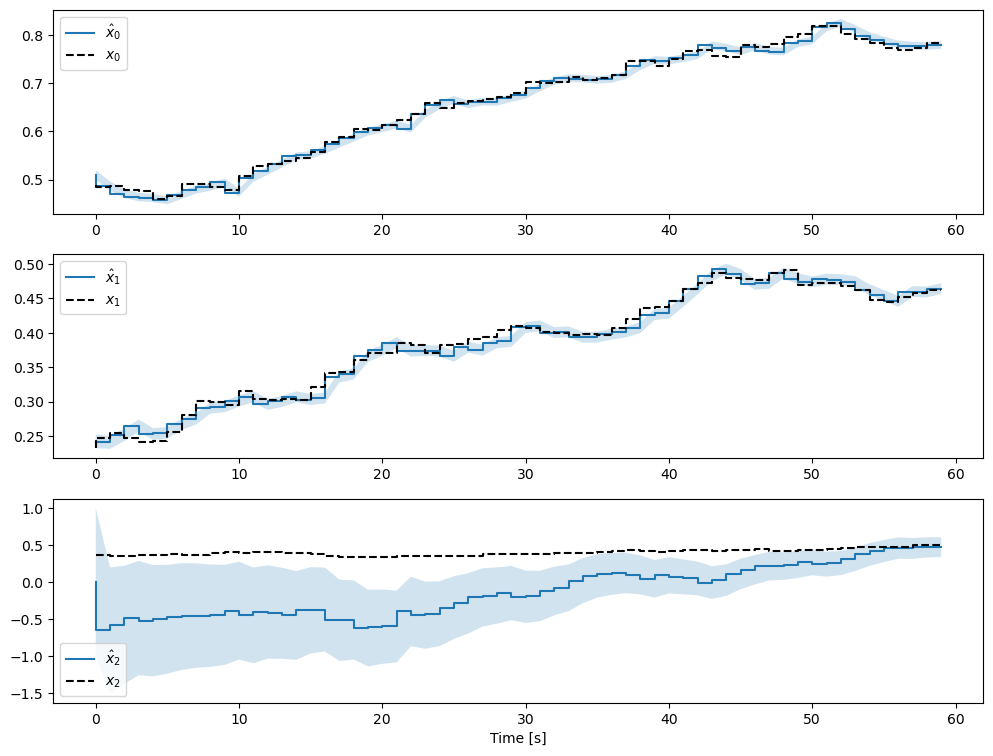

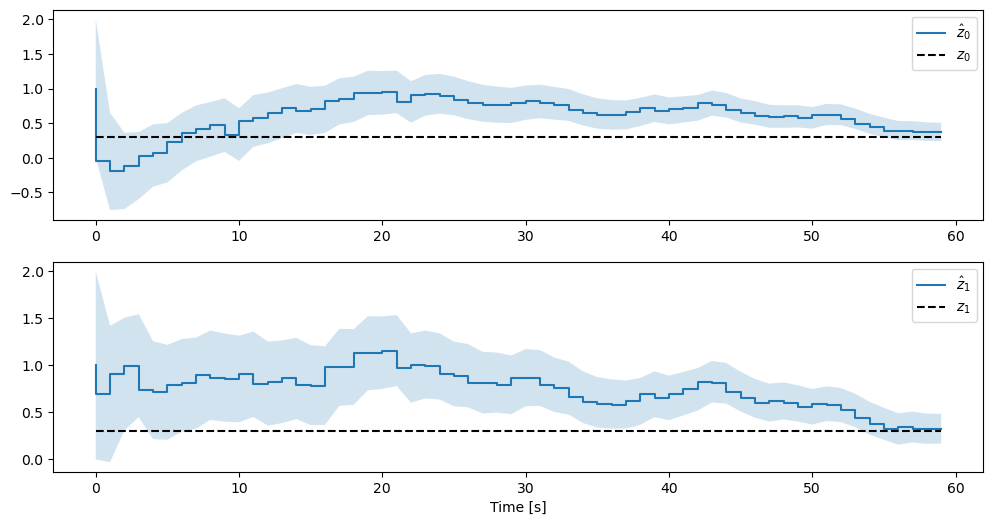

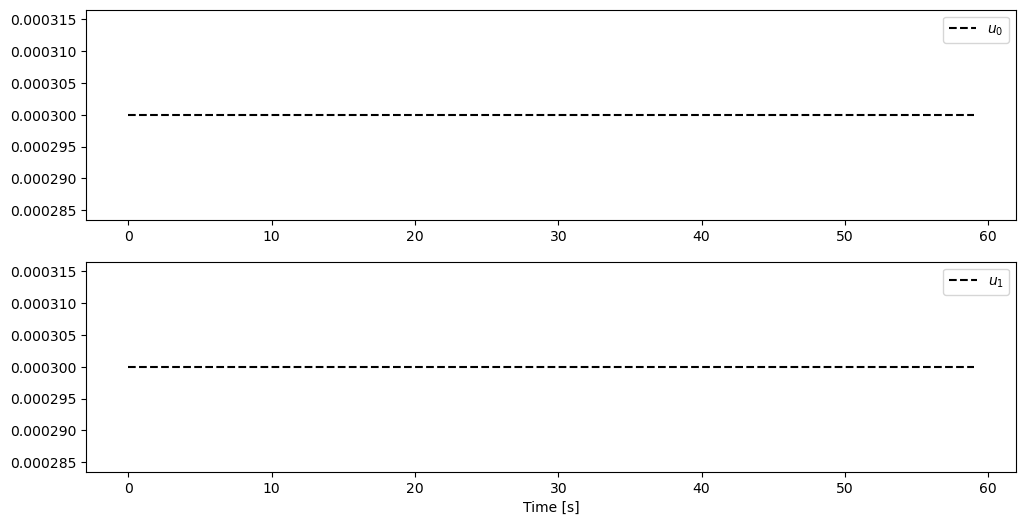

In [3]:
# define the system
h_equilibrium = jnp.array((0.489, 0.2332, 0.3611))
dssm = systems.ThreeTank.make(noise_std_x=1e-2, noise_std_y=1e-2, dt=1e-0, h_target=h_equilibrium)

# define the input and the fault signal
rng_key = jax.random.PRNGKey(0)
x0 = h_equilibrium
t = jnp.arange(0, 60, dssm.dt)
u_t = jnp.ones((len(t), dssm.input_dim)) * 3e-4
z_t = 0.3 * jnp.ones_like(u_t)

# simulate the system and the observer
_, x_t, y_t = dssm.simulate(x0, rng_key, u_t * z_t)
observer = observers.FaultObserver.from_dssm(dssm)
x_est, z_est = jax.vmap(observer.split)(observer.simulate(u_t, y_t))

# plot the results
plotting.plot_sim_result(t, u_t=u_t, x_t=x_t, x_est=x_est, z_t=z_t, z_est=z_est)